In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Using NumPy, create an array of 1000 random numbers drawn from a normal distribution with mean 0 and standard deviation 1. 
# Then, create a pandas DataFrame from this array with a single column named "Values". 
# Finally, use matplotlib.pyplot to plot a histogram of this data with 30 bins and customize the histogram color to blue.

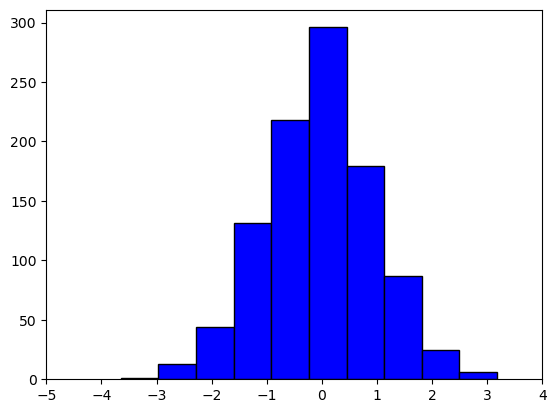

In [3]:
rng = np.random.default_rng(seed=42)
arr = rng.normal(loc=0.0, scale=1, size=1000)
df = pd.DataFrame({'Values' : arr})
plt.hist(arr, color='blue', edgecolor = 'black')
plt.xticks(np.arange(-5,5))
plt.show()

In [4]:
# Using the same DataFrame "df" from Question 1, create a new column called "Squared" that contains the square of the "Values" column. 
# Then, plot two subplots side by side: 
#         the left plot should be a scatter plot of "Values" vs "Squared", and 
#         the right plot should be a boxplot of the "Squared" values. 
# Make sure to include titles for both subplots.

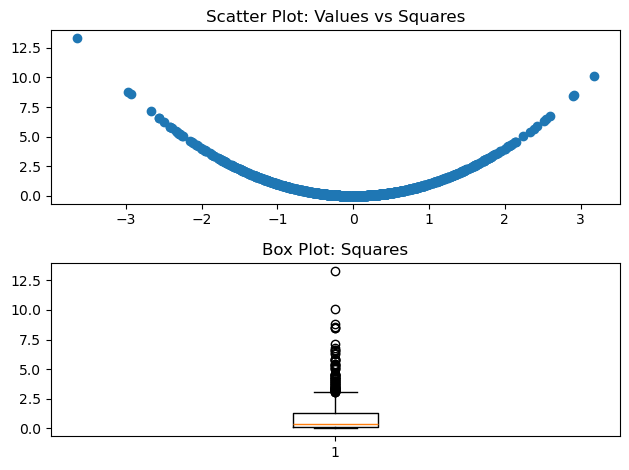

In [5]:
df['Squares'] = df['Values'] ** 2
# -----------scatter-------------
plt.subplot(2, 1, 1)
plt.title("Scatter Plot: Values vs Squares")
plt.scatter(df['Values'], df['Squares'])

plt.subplot(2, 1, 2)
plt.title("Box Plot: Squares")
plt.boxplot(df['Squares'])

plt.tight_layout()
plt.show()


In [6]:
# You are given a dataset containing the exam scores of students in three subjects: Math, Science, and English.

    # Load the dataset into a pandas DataFrame.
    # Use z-score to detect outliers in each subject column.
    # Define an outlier as any value with |z-score| > 3.
    # Perform two approaches to handle outliers:
        # Removal: Drop all rows containing outliers.
        # Capping: Replace outliers with the nearest valid boundary value (e.g., the maximum/minimum value within the non-outlier range).
    
    # Plot histograms (or boxplots) of the original, outlier-removed, and outlier-capped datasets using matplotlib to visually compare distributions.
    # Display the cleaned DataFrames after each method.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


np.random.seed(42)

# Generate exam scores (with some extreme outliers)
math_scores = np.random.normal(70, 10, 100).tolist() + [30, 150]
science_scores = np.random.normal(75, 12, 100).tolist() + [20, 160]
english_scores = np.random.normal(65, 8, 100).tolist() + [25, 140]


df = pd.DataFrame({
    "Math": math_scores,
    "Science": science_scores,
    "English": english_scores
})

print(df.head())


        Math    Science    English
0  74.967142  58.015551  67.862299
1  68.617357  69.952256  69.486276
2  76.476885  70.887426  73.664410
3  85.230299  65.372673  73.430416
4  67.658466  73.064571  53.978645


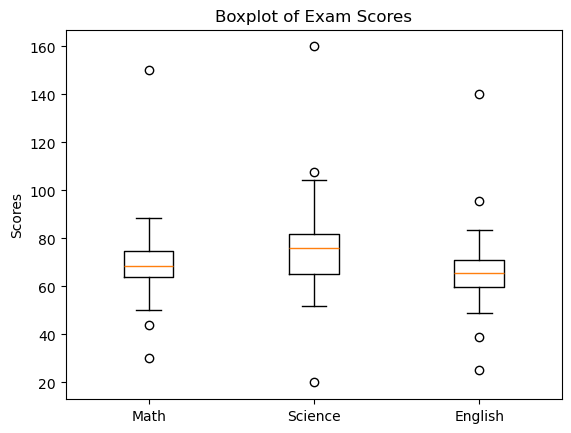

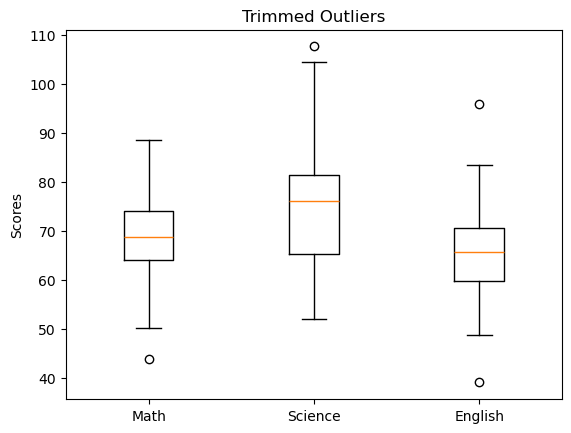

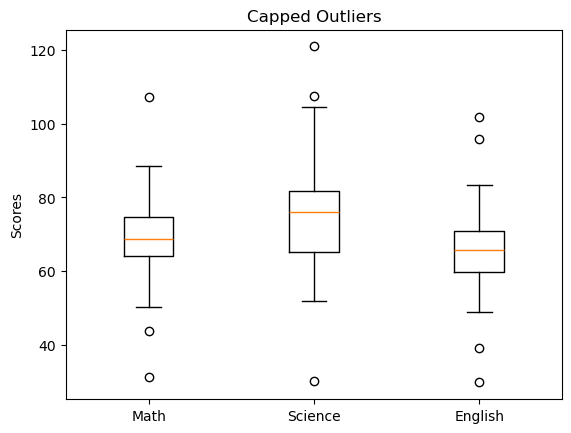

In [8]:
plt.boxplot(df.values, tick_labels=df.columns)
plt.title("Boxplot of Exam Scores")
plt.ylabel("Scores")
plt.show()


mean_subs = df.mean(axis = 0)
std_subs = df.std(axis = 0)
z_score = (df - mean_subs) / std_subs
outliers = df[z_score.abs() > 3]
trim_df = df[(z_score.abs() <= 3).all(axis = 1)]
lower_cap = mean_subs - 3 * std_subs
upper_cap = mean_subs + 3 * std_subs
cap_df = df.copy()
for col in df.columns:
    cap_df[col] = np.where(cap_df[col] < lower_cap[col], lower_cap[col], cap_df[col])
    cap_df[col] = np.where(cap_df[col] > upper_cap[col], upper_cap[col], cap_df[col])

plt.boxplot(trim_df.values, tick_labels = trim_df.columns)
plt.title("Trimmed Outliers")
plt.ylabel('Scores')
plt.show()


plt.boxplot(cap_df.values, tick_labels = cap_df.columns)
plt.title("Capped Outliers")
plt.ylabel('Scores')
plt.show()
